### Part III: Cross-Model Competition

#### Name: Tracy Chen, Hayley Shin (Group No: 7)

#### III.1 Local model set

Use at least 3 different local models. Run pairwise 2-player competitions for your chosen local models.

1. Generate one answer file per player/model. Use the same prompt and temperature settings across the models (optional: explore variations in prompt/temperature).
2. Judge each matchup by passing the relevant files to judge.py.
3. Use the returned CSV scores for analysis.

#### III.2 Analysis

Compare self-play for each local model and cross-play for each pair of local models.

Report at least:
- Average score per player against each opponent
-  Validity rates for each model
    
Discuss what it means for models to do differently well against themselves than they do against other models, and the role of temperature in that behavior. Hint: what happens when a low temperature model plays against itself?

##### Compare self-play for each local model

In [1]:
# import library
import math
import json
import random
import subprocess
import sys
from collections import Counter, defaultdict
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [39]:
# load data
scores_QQ = pd.read_csv("outputs/scores_QQ.csv")
scores_MM = pd.read_csv("outputs/scores_MM.csv")
scores_LL = pd.read_csv("outputs/scores_LL.csv")
scores_QQ_t04 = pd.read_csv("outputs/scores_QQ_T0.4.csv")
scores_MM_t04 = pd.read_csv("outputs/scores_MM_T0.4.csv")
scores_LL_t04 = pd.read_csv("outputs/scores_LL_T0.4.csv")

# add column
for df in [scores_QQ, scores_MM, scores_LL, scores_QQ_t04, scores_MM_t04, scores_LL_t04]:
    df["collision_rate_of_valid"] = df["collisions"] / df["valid_answers"]

# df for comparison
rows = []
for label, df in [("qwen2.5:7b", scores_QQ), ("mistral:7b", scores_MM), ("llama3.2:3b", scores_LL),]:
    rows.append({"model": label,
                 "valid_rate": df["valid_rate"].mean(),
                 "collision_rate": df["collision_rate"].mean(),
                 "collision_rate_of_valid": df["collision_rate_of_valid"].mean(),
                 "avg_points_per_answer": df["avg_points_per_answer"].mean(),})
compare_self_model = pd.DataFrame(rows)
compare_self_model

,model,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,qwen2.5:7b,0.715234,0.436719,0.610749,0.278516
1,mistral:7b,0.718750,0.412500,0.573914,0.306250
2,llama3.2:3b,0.735547,0.357812,0.486573,0.377734


In [ ]:
# Self-Play : qwen2.5:7b
scores_QQ[["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]]

,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,0.726562,0.436719,0.601075,0.289844
1,0.703906,0.436719,0.620422,0.267188


In [ ]:
# Self-Play : mistral:7b
scores_MM[["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]]

,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,0.717969,0.4125,0.574538,0.305469
1,0.719531,0.4125,0.573290,0.307031


In [ ]:
# Self-Play : llama3.2:3b
scores_LL[["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]]

,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,0.746875,0.357812,0.479079,0.389062
1,0.724219,0.357812,0.494067,0.366406


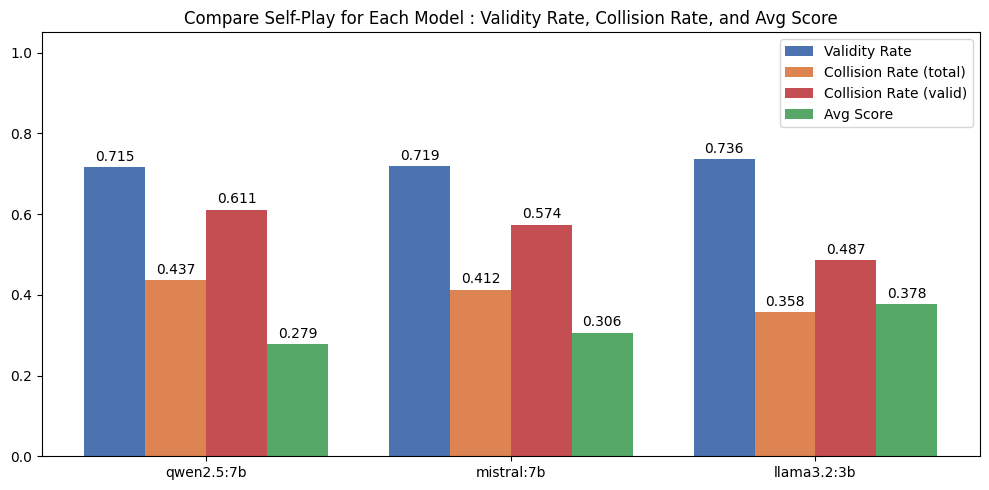

In [ ]:
# plot for comparing self-play for each local model
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

models = compare_self_model["model"].tolist()
x = np.arange(len(models))
w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_self_model[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_self_model[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Compare Self-Play for Each Model : Validity Rate, Collision Rate, and Avg Score")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [40]:
# df for comparison
rows = []
for label, df in [("T=0.4 qwen2.5:7b", scores_QQ_t04), ("T=0.4 mistral:7b", scores_MM_t04), ("T=0.4 llama3.2:3b", scores_LL_t04), 
                  ("T=0.8 qwen2.5:7b", scores_QQ), ("T=0.8 mistral:7b", scores_MM), ("T=0.8 llama3.2:3b", scores_LL),]:
    rows.append({"setting": label,
                 "valid_rate": df["valid_rate"].mean(),
                 "collision_rate": df["collision_rate"].mean(),
                 "collision_rate_of_valid": df["collision_rate_of_valid"].mean(),
                 "avg_points_per_answer": df["avg_points_per_answer"].mean(),})
compare_self_model2 = pd.DataFrame(rows)
compare_self_model2

,setting,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,T=0.4 qwen2.5:7b,0.747266,0.565625,0.756927,0.181641
1,T=0.4 mistral:7b,0.755078,0.578125,0.765659,0.176953
2,T=0.4 llama3.2:3b,0.769922,0.546094,0.709315,0.223828
3,T=0.8 qwen2.5:7b,0.715234,0.436719,0.610749,0.278516
4,T=0.8 mistral:7b,0.718750,0.412500,0.573914,0.306250
5,T=0.8 llama3.2:3b,0.735547,0.357812,0.486573,0.377734


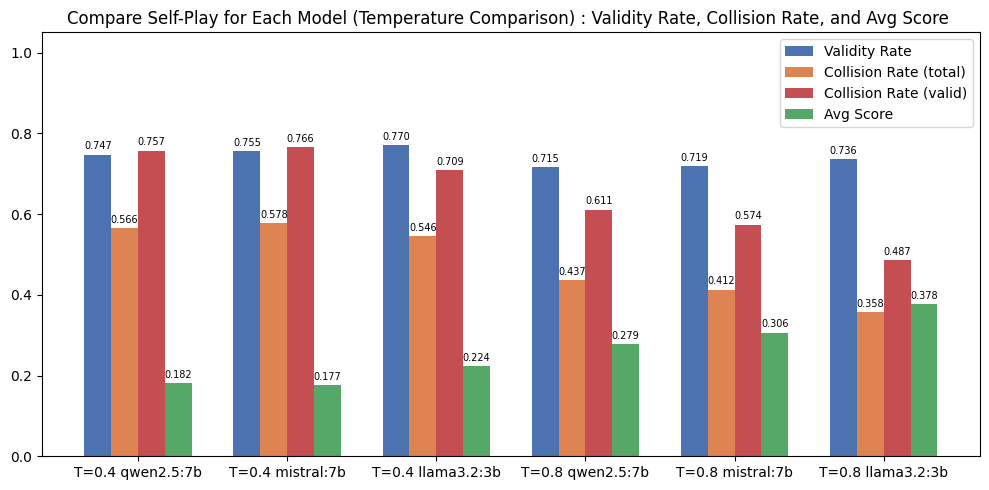

In [41]:
# plot for cross-play temperature comparison
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

settings = compare_self_model2["setting"].tolist()
x = np.arange(len(settings))
w = 0.18
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_self_model2[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_self_model2[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=7)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(settings, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Compare Self-Play for Each Model (Temperature Comparison) : Validity Rate, Collision Rate, and Avg Score ")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

##### Cross-play : qwen2.5:7b vs mistral:7b

In [15]:
# load data
scores_QM = pd.read_csv("outputs/scores_QM.csv")
scores_QM_t04 = pd.read_csv("outputs/scores_QM_T0.4.csv")
scores_QM_t15 = pd.read_csv("outputs/scores_QM_T1.5.csv")
scores_QM_prompt2 = pd.read_csv("outputs/scores_QM_prompt2.csv")

# add column
for df in [scores_QM, scores_QM_t04, scores_QM_t15, scores_QM_prompt2]:
    df["collision_rate_of_valid"] = df["collisions"] / df["valid_answers"]
    df["model"] = ["mistral:7b", "qwen2.5:7b"]

In [ ]:
# Cross-Play : qwen2.5:7b vs mistral:7b (baseline)
scores_QM[["model", "valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]]

,model,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,mistral:7b,0.717969,0.194531,0.270947,0.523438
1,qwen2.5:7b,0.726562,0.194531,0.267742,0.532031


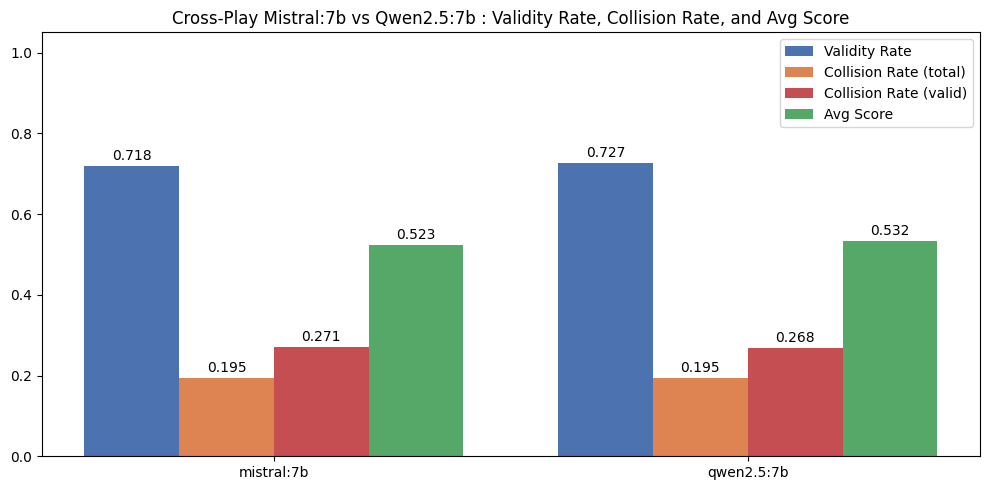

In [23]:
# plot for cross-play: qwen2.5:7b vs mistral:7b
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

models = scores_QM["model"].tolist()
x = np.arange(len(models))
w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, scores_QM[a], w, label=lbl, color=col)
    for bar, v in zip(bars, scores_QM[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Play Mistral:7b vs Qwen2.5:7b : Validity Rate, Collision Rate, and Avg Score")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [26]:
# compare cross-play outcomes with self-play outcomes
model1 = "qwen2.5:7b"
model2 = "mistral:7b"
self_m1 = compare_self_model[compare_self_model["model"] == model1].iloc[0]
self_m2 = compare_self_model[compare_self_model["model"] == model2].iloc[0]
cross_m1 = scores_QM[scores_QM["model"] == model1].iloc[0]
cross_m2 = scores_QM[scores_QM["model"] == model2].iloc[0]
# df for comparison
rows = []
for label, df in [(f"self-play {model1}", self_m1), (f"self-play {model2}", self_m2), (f"cross-play {model1}", cross_m1), (f"cross-play {model2}", cross_m2),]:
    rows.append({"model": label,
                 "valid_rate": df["valid_rate"],
                 "collision_rate": df["collision_rate"],
                 "collision_rate_of_valid": df["collision_rate_of_valid"],
                 "avg_points_per_answer": df["avg_points_per_answer"],})
compare_self_cross = pd.DataFrame(rows)
compare_self_cross

,model,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,self-play qwen2.5:7b,0.715234,0.436719,0.610749,0.278516
1,self-play mistral:7b,0.718750,0.412500,0.573914,0.306250
2,cross-play qwen2.5:7b,0.726562,0.194531,0.267742,0.532031
3,cross-play mistral:7b,0.717969,0.194531,0.270947,0.523438


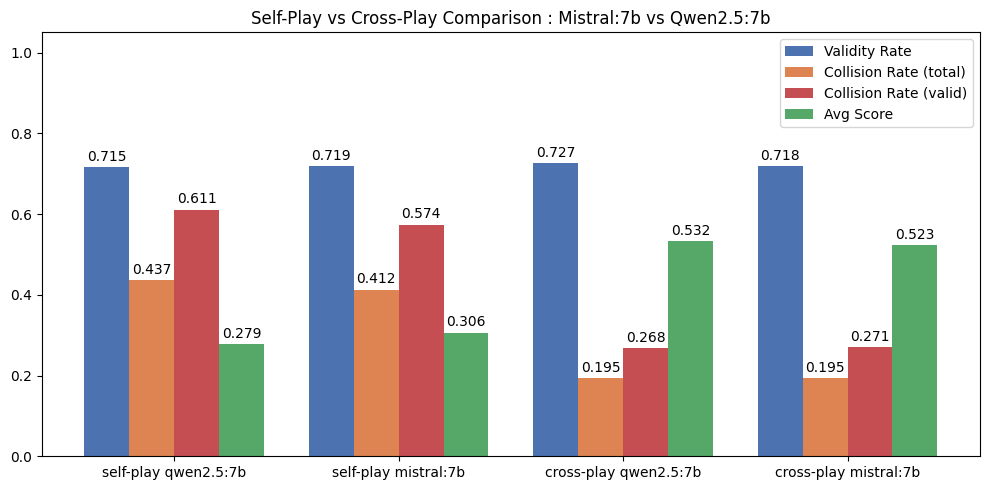

In [29]:
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

x = np.arange(len(compare_self_cross))
w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_self_cross[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_self_cross[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(compare_self_cross["model"], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Self-Play vs Cross-Play Comparison : Mistral:7b vs Qwen2.5:7b")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# explore variations in temperature
cross_m1_t04 = scores_QM_t04[scores_QM_t04["model"] == model1].iloc[0]
cross_m2_t04 = scores_QM_t04[scores_QM_t04["model"] == model2].iloc[0]
cross_m1_t15 = scores_QM_t15[scores_QM_t15["model"] == model1].iloc[0]
cross_m2_t15 = scores_QM_t15[scores_QM_t15["model"] == model2].iloc[0]
# df for comparison
rows = []
for label, df in [(f"T=0.4 {model1}", cross_m1_t04), (f"T=0.4 {model2}", cross_m2_t04), 
                  (f"T=0.8 {model1}", cross_m1), (f"T=0.8 {model2}", cross_m2), 
                  (f"T=1.5 {model1}", cross_m1_t15), (f"T=1.5 {model2}", cross_m2_t15),]:
    rows.append({"setting": label,
                 "valid_rate": df["valid_rate"],
                 "collision_rate": df["collision_rate"],
                 "collision_rate_of_valid": df["collision_rate_of_valid"],
                 "avg_points_per_answer": df["avg_points_per_answer"],})
compare_cross_temp = pd.DataFrame(rows)
compare_cross_temp

,setting,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,T=0.4 qwen2.5:7b,0.746875,0.230469,0.308577,0.516406
1,T=0.4 mistral:7b,0.757812,0.230469,0.304124,0.527344
2,T=0.8 qwen2.5:7b,0.726562,0.194531,0.267742,0.532031
3,T=0.8 mistral:7b,0.717969,0.194531,0.270947,0.523438
4,T=1.5 qwen2.5:7b,0.685156,0.162500,0.237172,0.522656
5,T=1.5 mistral:7b,0.702344,0.162500,0.231368,0.539844


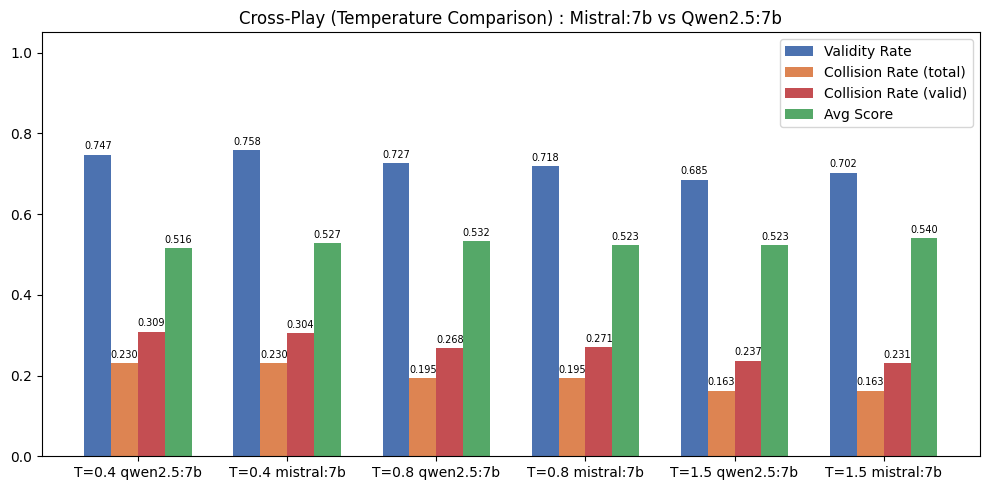

In [36]:
# plot for cross-play temperature comparison
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

settings = compare_cross_temp["setting"].tolist()
x = np.arange(len(settings))
w = 0.18
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_cross_temp[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_cross_temp[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=7)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(settings, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Play (Temperature Comparison) : Mistral:7b vs Qwen2.5:7b")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [37]:
# explore variations in prompt
cross_m1_p2 = scores_QM_prompt2[scores_QM_prompt2["model"] == model1].iloc[0]
cross_m2_p2 = scores_QM_prompt2[scores_QM_prompt2["model"] == model2].iloc[0]
# df for comparison
rows = []
for label, df in [(f"prompt1 {model1}", cross_m1), (f"prompt1 {model2}", cross_m2), 
                  (f"prompt2 {model1}", cross_m1_p2), (f"prompt2 {model2}", cross_m2_p2),]:
    rows.append({"setting": label,
                 "valid_rate": df["valid_rate"],
                 "collision_rate": df["collision_rate"],
                 "collision_rate_of_valid": df["collision_rate_of_valid"],
                 "avg_points_per_answer": df["avg_points_per_answer"],})
compare_cross_prompt = pd.DataFrame(rows)
compare_cross_prompt

,setting,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,prompt1 qwen2.5:7b,0.726562,0.194531,0.267742,0.532031
1,prompt1 mistral:7b,0.717969,0.194531,0.270947,0.523438
2,prompt2 qwen2.5:7b,0.700000,0.078906,0.112723,0.621094
3,prompt2 mistral:7b,0.552344,0.078906,0.142857,0.473438


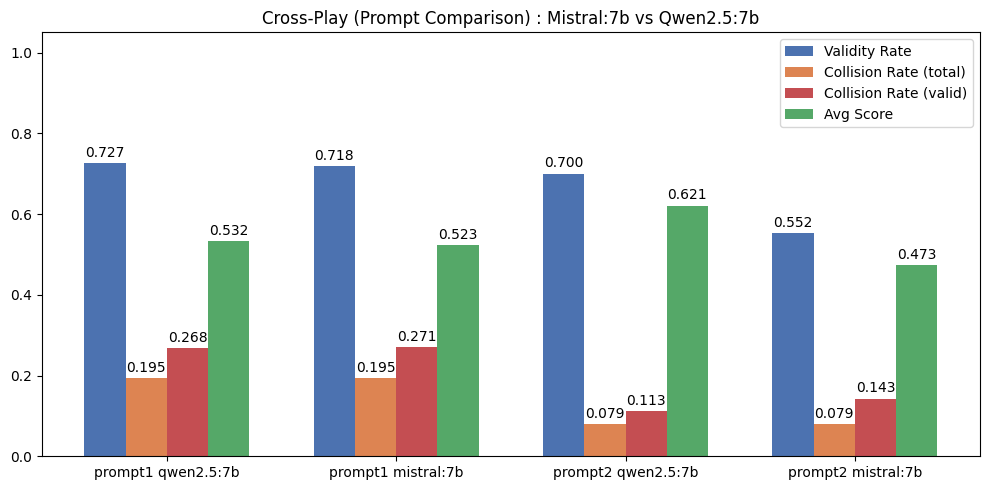

In [38]:
# plot for cross-play prompt comparison
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

settings = compare_cross_prompt["setting"].tolist()
x = np.arange(len(settings))
w = 0.18
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_cross_prompt[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_cross_prompt[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(settings, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Play (Prompt Comparison) : Mistral:7b vs Qwen2.5:7b")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

##### Cross-play : qwen2.5:7b vs llama3.2:3b

In [42]:
# load data
scores_QL = pd.read_csv("outputs/scores_QL.csv")
scores_QL_t04 = pd.read_csv("outputs/scores_QL_T0.4.csv")
scores_QL_t15 = pd.read_csv("outputs/scores_QL_T1.5.csv")
scores_QL_prompt2 = pd.read_csv("outputs/scores_QL_prompt2.csv")

# add column
for df in [scores_QL, scores_QL_t04, scores_QL_t15, scores_QL_prompt2]:
    df["collision_rate_of_valid"] = df["collisions"] / df["valid_answers"]
    df["model"] = ["llama3.2:3b", "qwen2.5:7b"]

In [43]:
# Cross-Play : qwen2.5:7b vs llama3.2:3b (baseline)
scores_QL[["model", "valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]]

,model,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,llama3.2:3b,0.746875,0.225,0.301255,0.521875
1,qwen2.5:7b,0.726562,0.225,0.309677,0.501563


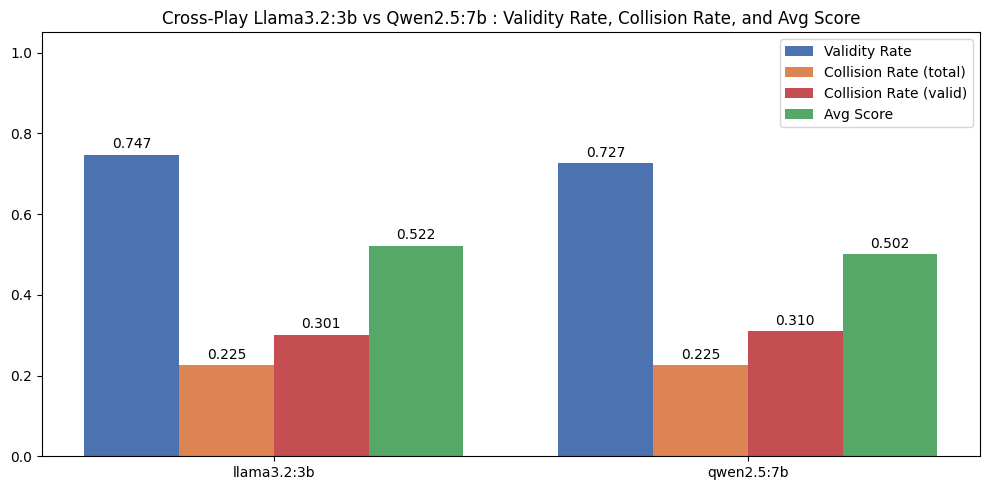

In [44]:
# plot for cross-play: qwen2.5:7b vs llama3.2:3b
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

models = scores_QL["model"].tolist()
x = np.arange(len(models))
w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, scores_QL[a], w, label=lbl, color=col)
    for bar, v in zip(bars, scores_QL[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Play Llama3.2:3b vs Qwen2.5:7b : Validity Rate, Collision Rate, and Avg Score")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [45]:
# compare cross-play outcomes with self-play outcomes
model1 = "qwen2.5:7b"
model2 = "llama3.2:3b"
self_m1 = compare_self_model[compare_self_model["model"] == model1].iloc[0]
self_m2 = compare_self_model[compare_self_model["model"] == model2].iloc[0]
cross_m1 = scores_QL[scores_QL["model"] == model1].iloc[0]
cross_m2 = scores_QL[scores_QL["model"] == model2].iloc[0]
# df for comparison
rows = []
for label, df in [(f"self-play {model1}", self_m1), (f"self-play {model2}", self_m2), (f"cross-play {model1}", cross_m1), (f"cross-play {model2}", cross_m2),]:
    rows.append({"model": label,
                 "valid_rate": df["valid_rate"],
                 "collision_rate": df["collision_rate"],
                 "collision_rate_of_valid": df["collision_rate_of_valid"],
                 "avg_points_per_answer": df["avg_points_per_answer"],})
compare_self_cross = pd.DataFrame(rows)
compare_self_cross

,model,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,self-play qwen2.5:7b,0.715234,0.436719,0.610749,0.278516
1,self-play llama3.2:3b,0.735547,0.357812,0.486573,0.377734
2,cross-play qwen2.5:7b,0.726562,0.225000,0.309677,0.501563
3,cross-play llama3.2:3b,0.746875,0.225000,0.301255,0.521875


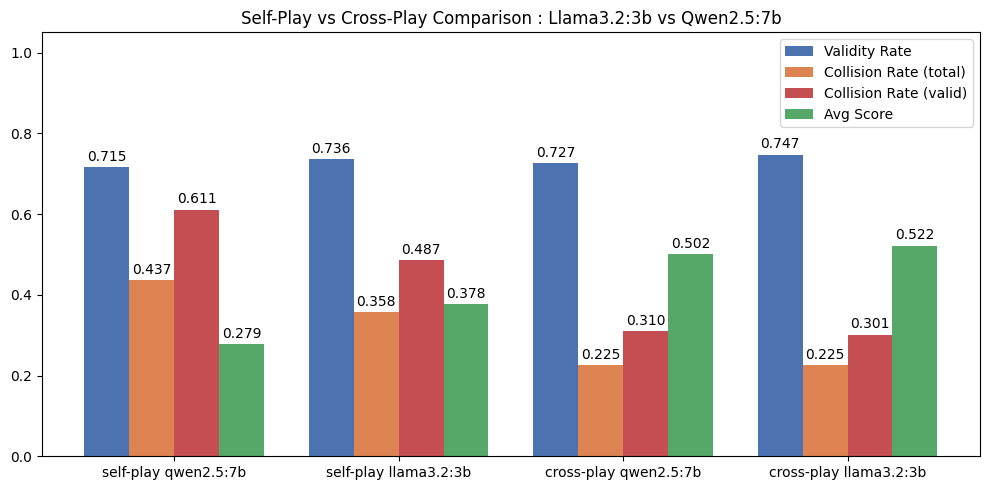

In [46]:
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

x = np.arange(len(compare_self_cross))
w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_self_cross[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_self_cross[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(compare_self_cross["model"], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Self-Play vs Cross-Play Comparison : Llama3.2:3b vs Qwen2.5:7b")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [47]:
# explore variations in temperature
cross_m1_t04 = scores_QL_t04[scores_QL_t04["model"] == model1].iloc[0]
cross_m2_t04 = scores_QL_t04[scores_QL_t04["model"] == model2].iloc[0]
cross_m1_t15 = scores_QL_t15[scores_QL_t15["model"] == model1].iloc[0]
cross_m2_t15 = scores_QL_t15[scores_QL_t15["model"] == model2].iloc[0]
# df for comparison
rows = []
for label, df in [(f"T=0.4 {model1}", cross_m1_t04), (f"T=0.4 {model2}", cross_m2_t04), 
                  (f"T=0.8 {model1}", cross_m1), (f"T=0.8 {model2}", cross_m2), 
                  (f"T=1.5 {model1}", cross_m1_t15), (f"T=1.5 {model2}", cross_m2_t15),]:
    rows.append({"setting": label,
                 "valid_rate": df["valid_rate"],
                 "collision_rate": df["collision_rate"],
                 "collision_rate_of_valid": df["collision_rate_of_valid"],
                 "avg_points_per_answer": df["avg_points_per_answer"],})
compare_cross_temp = pd.DataFrame(rows)
compare_cross_temp

,setting,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,T=0.4 qwen2.5:7b,0.746875,0.285938,0.382845,0.460938
1,T=0.4 llama3.2:3b,0.775000,0.285938,0.368952,0.489063
2,T=0.8 qwen2.5:7b,0.726562,0.225000,0.309677,0.501563
3,T=0.8 llama3.2:3b,0.746875,0.225000,0.301255,0.521875
4,T=1.5 qwen2.5:7b,0.685156,0.184375,0.269099,0.500781
5,T=1.5 llama3.2:3b,0.690625,0.184375,0.266968,0.506250


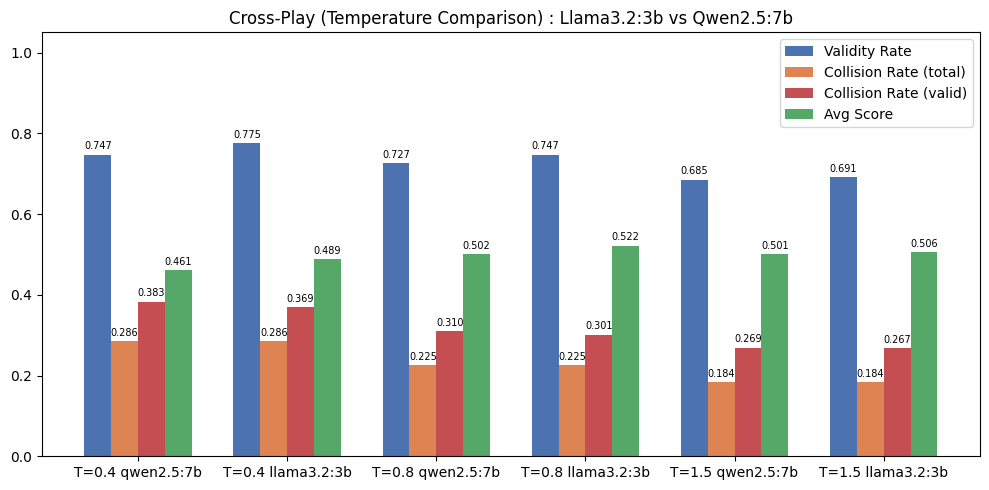

In [48]:
# plot for cross-play temperature comparison
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

settings = compare_cross_temp["setting"].tolist()
x = np.arange(len(settings))
w = 0.18
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_cross_temp[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_cross_temp[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=7)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(settings, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Play (Temperature Comparison) : Llama3.2:3b vs Qwen2.5:7b")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [49]:
# explore variations in prompt
cross_m1_p2 = scores_QL_prompt2[scores_QL_prompt2["model"] == model1].iloc[0]
cross_m2_p2 = scores_QL_prompt2[scores_QL_prompt2["model"] == model2].iloc[0]
# df for comparison
rows = []
for label, df in [(f"prompt1 {model1}", cross_m1), (f"prompt1 {model2}", cross_m2), 
                  (f"prompt2 {model1}", cross_m1_p2), (f"prompt2 {model2}", cross_m2_p2),]:
    rows.append({"setting": label,
                 "valid_rate": df["valid_rate"],
                 "collision_rate": df["collision_rate"],
                 "collision_rate_of_valid": df["collision_rate_of_valid"],
                 "avg_points_per_answer": df["avg_points_per_answer"],})
compare_cross_prompt = pd.DataFrame(rows)
compare_cross_prompt

,setting,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,prompt1 qwen2.5:7b,0.726562,0.225000,0.309677,0.501563
1,prompt1 llama3.2:3b,0.746875,0.225000,0.301255,0.521875
2,prompt2 qwen2.5:7b,0.700000,0.153125,0.218750,0.546875
3,prompt2 llama3.2:3b,0.758594,0.153125,0.201854,0.605469


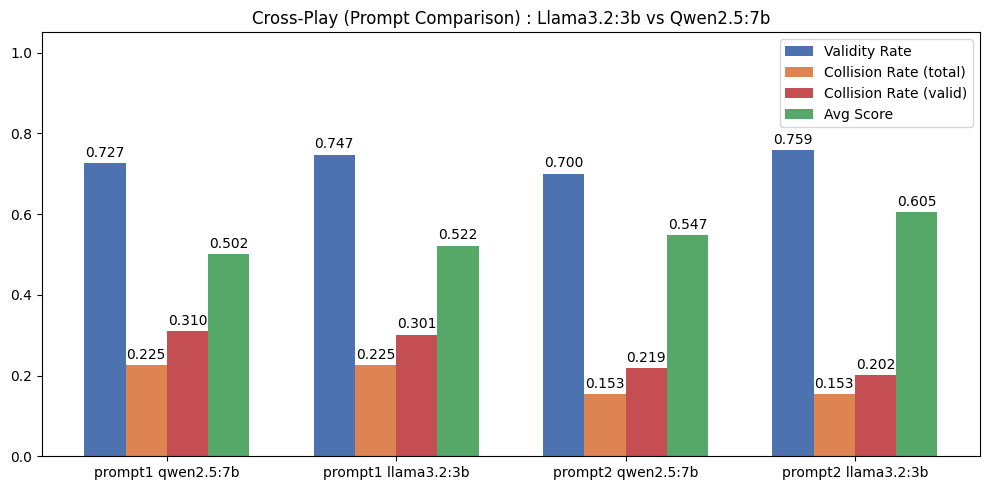

In [50]:
# plot for cross-play prompt comparison
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

settings = compare_cross_prompt["setting"].tolist()
x = np.arange(len(settings))
w = 0.18
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_cross_prompt[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_cross_prompt[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(settings, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Play (Prompt Comparison) : Llama3.2:3b vs Qwen2.5:7b")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

##### Cross-play : mistral:7b vs llama3.2:3b

In [51]:
# load data
scores_ML = pd.read_csv("outputs/scores_ML.csv")
scores_ML_t04 = pd.read_csv("outputs/scores_ML_T0.4.csv")
scores_ML_t15 = pd.read_csv("outputs/scores_ML_T1.5.csv")
scores_ML_prompt2 = pd.read_csv("outputs/scores_ML_prompt2.csv")

# add column
for df in [scores_ML, scores_ML_t04, scores_ML_t15, scores_ML_prompt2]:
    df["collision_rate_of_valid"] = df["collisions"] / df["valid_answers"]
    df["model"] = ["llama3.2:3b", "mistral:7b"]

In [52]:
# Cross-Play : mistral:7b vs llama3.2:3b (baseline)
scores_ML[["model", "valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]]

,model,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,llama3.2:3b,0.746875,0.167969,0.224895,0.578906
1,mistral:7b,0.717969,0.167969,0.233950,0.550000


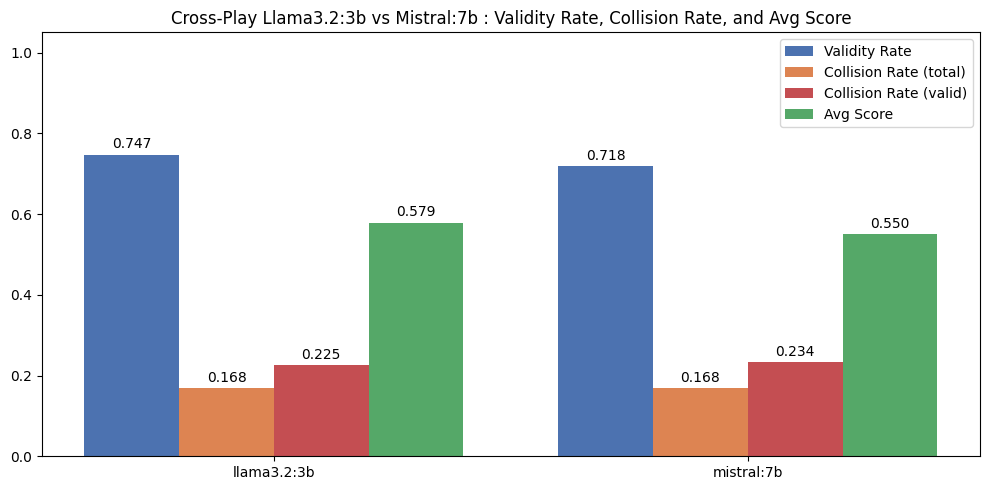

In [53]:
# plot for cross-play: mistral:7b vs llama3.2:3b
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

models = scores_ML["model"].tolist()
x = np.arange(len(models))
w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, scores_ML[a], w, label=lbl, color=col)
    for bar, v in zip(bars, scores_ML[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Play Llama3.2:3b vs Mistral:7b : Validity Rate, Collision Rate, and Avg Score")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [54]:
# compare cross-play outcomes with self-play outcomes
model1 = "mistral:7b"
model2 = "llama3.2:3b"
self_m1 = compare_self_model[compare_self_model["model"] == model1].iloc[0]
self_m2 = compare_self_model[compare_self_model["model"] == model2].iloc[0]
cross_m1 = scores_ML[scores_ML["model"] == model1].iloc[0]
cross_m2 = scores_ML[scores_ML["model"] == model2].iloc[0]
# df for comparison
rows = []
for label, df in [(f"self-play {model1}", self_m1), (f"self-play {model2}", self_m2), (f"cross-play {model1}", cross_m1), (f"cross-play {model2}", cross_m2),]:
    rows.append({"model": label,
                 "valid_rate": df["valid_rate"],
                 "collision_rate": df["collision_rate"],
                 "collision_rate_of_valid": df["collision_rate_of_valid"],
                 "avg_points_per_answer": df["avg_points_per_answer"],})
compare_self_cross = pd.DataFrame(rows)
compare_self_cross

,model,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,self-play mistral:7b,0.718750,0.412500,0.573914,0.306250
1,self-play llama3.2:3b,0.735547,0.357812,0.486573,0.377734
2,cross-play mistral:7b,0.717969,0.167969,0.233950,0.550000
3,cross-play llama3.2:3b,0.746875,0.167969,0.224895,0.578906


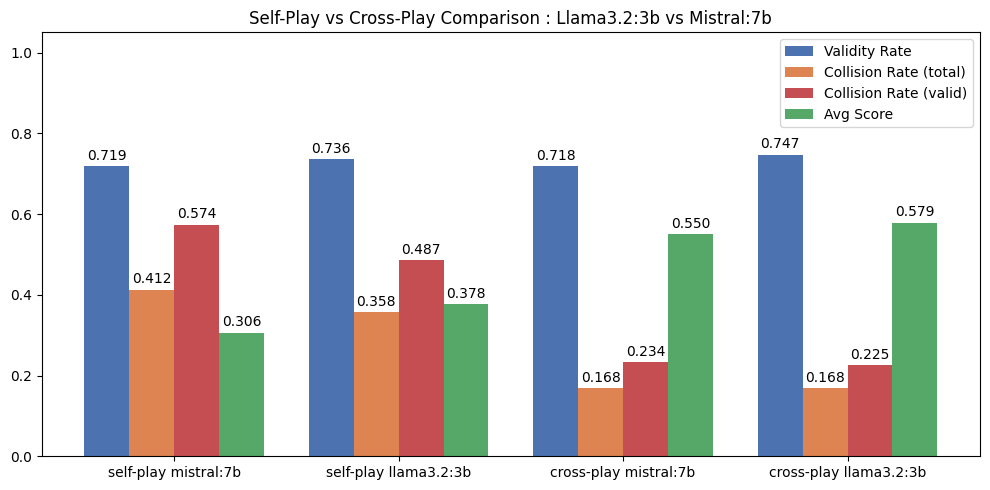

In [55]:
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

x = np.arange(len(compare_self_cross))
w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_self_cross[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_self_cross[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(compare_self_cross["model"], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Self-Play vs Cross-Play Comparison : Llama3.2:3b vs Mistral:7b")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [56]:
# explore variations in temperature
cross_m1_t04 = scores_ML_t04[scores_ML_t04["model"] == model1].iloc[0]
cross_m2_t04 = scores_ML_t04[scores_ML_t04["model"] == model2].iloc[0]
cross_m1_t15 = scores_ML_t15[scores_ML_t15["model"] == model1].iloc[0]
cross_m2_t15 = scores_ML_t15[scores_ML_t15["model"] == model2].iloc[0]
# df for comparison
rows = []
for label, df in [(f"T=0.4 {model1}", cross_m1_t04), (f"T=0.4 {model2}", cross_m2_t04), 
                  (f"T=0.8 {model1}", cross_m1), (f"T=0.8 {model2}", cross_m2), 
                  (f"T=1.5 {model1}", cross_m1_t15), (f"T=1.5 {model2}", cross_m2_t15),]:
    rows.append({"setting": label,
                 "valid_rate": df["valid_rate"],
                 "collision_rate": df["collision_rate"],
                 "collision_rate_of_valid": df["collision_rate_of_valid"],
                 "avg_points_per_answer": df["avg_points_per_answer"],})
compare_cross_temp = pd.DataFrame(rows)
compare_cross_temp

,setting,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,T=0.4 mistral:7b,0.757812,0.210938,0.278351,0.546875
1,T=0.4 llama3.2:3b,0.775000,0.210938,0.272177,0.564063
2,T=0.8 mistral:7b,0.717969,0.167969,0.233950,0.550000
3,T=0.8 llama3.2:3b,0.746875,0.167969,0.224895,0.578906
4,T=1.5 mistral:7b,0.702344,0.117188,0.166852,0.585156
5,T=1.5 llama3.2:3b,0.690625,0.117188,0.169683,0.573438


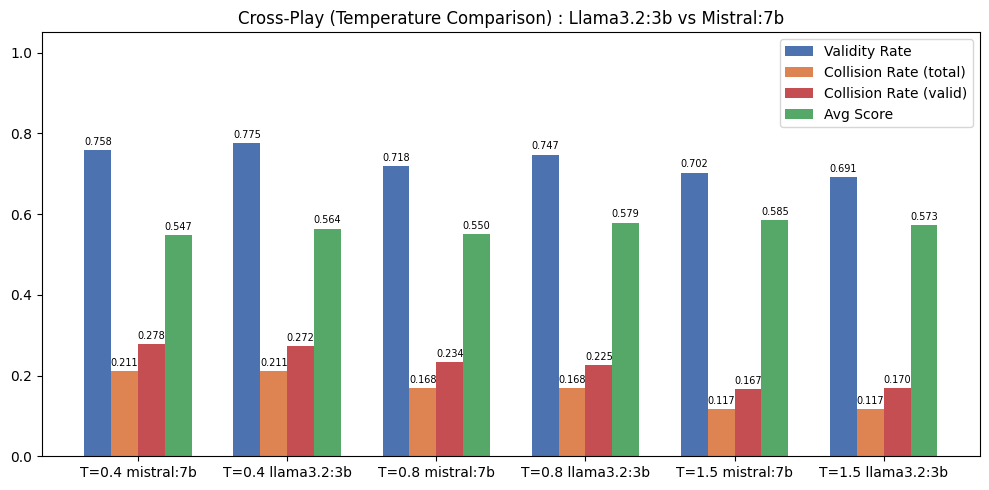

In [57]:
# plot for cross-play temperature comparison
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

settings = compare_cross_temp["setting"].tolist()
x = np.arange(len(settings))
w = 0.18
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_cross_temp[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_cross_temp[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=7)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(settings, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Play (Temperature Comparison) : Llama3.2:3b vs Mistral:7b")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [58]:
# explore variations in prompt
cross_m1_p2 = scores_ML_prompt2[scores_ML_prompt2["model"] == model1].iloc[0]
cross_m2_p2 = scores_ML_prompt2[scores_ML_prompt2["model"] == model2].iloc[0]
# df for comparison
rows = []
for label, df in [(f"prompt1 {model1}", cross_m1), (f"prompt1 {model2}", cross_m2), 
                  (f"prompt2 {model1}", cross_m1_p2), (f"prompt2 {model2}", cross_m2_p2),]:
    rows.append({"setting": label,
                 "valid_rate": df["valid_rate"],
                 "collision_rate": df["collision_rate"],
                 "collision_rate_of_valid": df["collision_rate_of_valid"],
                 "avg_points_per_answer": df["avg_points_per_answer"],})
compare_cross_prompt = pd.DataFrame(rows)
compare_cross_prompt

,setting,valid_rate,collision_rate,collision_rate_of_valid,avg_points_per_answer
0,prompt1 mistral:7b,0.717969,0.167969,0.233950,0.550000
1,prompt1 llama3.2:3b,0.746875,0.167969,0.224895,0.578906
2,prompt2 mistral:7b,0.552344,0.075000,0.135785,0.477344
3,prompt2 llama3.2:3b,0.758594,0.075000,0.098867,0.683594


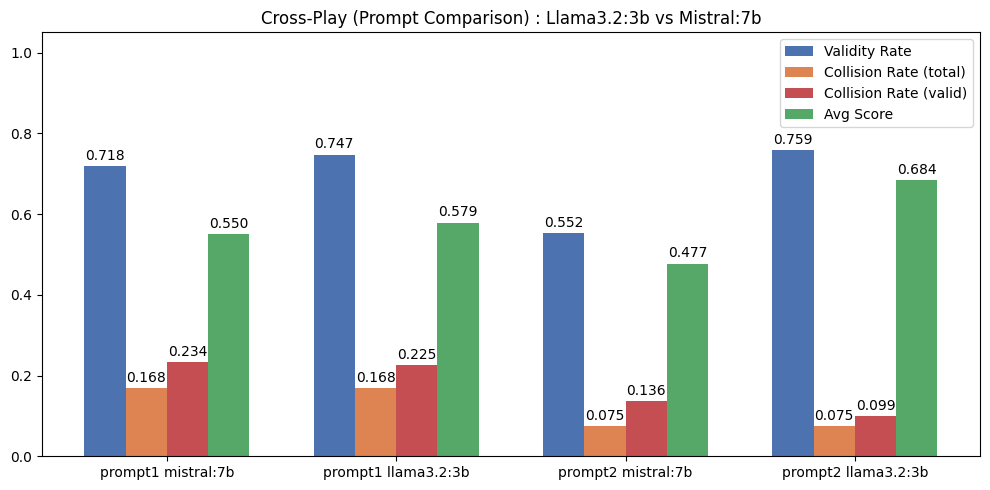

In [59]:
# plot for cross-play prompt comparison
values = ["valid_rate", "collision_rate", "collision_rate_of_valid", "avg_points_per_answer"]
labels = ["Validity Rate", "Collision Rate (total)", "Collision Rate (valid)", "Avg Score"]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

settings = compare_cross_prompt["setting"].tolist()
x = np.arange(len(settings))
w = 0.18
fig, ax = plt.subplots(figsize=(10, 5))
for i, (a, lbl, col) in enumerate(zip(values, labels, colors)):
    bars = ax.bar(x + i * w, compare_cross_prompt[a], w, label=lbl, color=col)
    for bar, v in zip(bars, compare_cross_prompt[a]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10)
ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(settings, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Cross-Play (Prompt Comparison) : Llama3.2:3b vs Mistral:7b")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()